# Test the CMAC: predicting 3 seconds ahead on the 7-position back-and-forth movement

This notebook checks whether `CMAC3` (see [`cmac.py`](../cmac.py)) can actually learn to
predict the target's position `TIME_OF_FLIGHT` seconds ahead (see [`config.py`](../config.py),
currently 3 s), when the target itself is doing the same discrete back-and-forth movement used
to build the training data in
[`get_angles_for_nn.ipynb`](get_angles_for_nn.ipynb): it visits the same 7 measured pixel
positions in order, one at a time, then reverses -- like a metronome swinging across 7 marks --
at a rhythm of 50 BPM (beats per minute).

The question this answers: if you feed the CMAC 3 *consecutive* movements (3 of the 7 pixel
values, one beat apart) as `x1, x2, x3`, does it correctly predict where the target will be
3 seconds later?


In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Notebook lives in Project_final/notebooks/ -- add Project_final/ itself to sys.path
# so we can import the same cmac.py / config.py / reporting.py the rest of the project uses
# (same pattern camera_to_angle.py uses for its own sys.path setup).
PROJECT_DIR = Path.cwd().parent
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from cmac import CMAC3
from config import N_CENTERS, TIME_OF_FLIGHT, MSE_WINDOW
from reporting import plot_prediction, report_learning


## 1. The movement: 7 positions, back-and-forth, at 50 BPM

Same 7 measured `pixel_x` positions as `get_angles_for_nn.ipynb` (left -> right across the
camera frame). "50 BPM" fixes how long the target dwells on each position before stepping to
the next one -- like a metronome: `60 / 50 = 1.2 s` per beat/step. The target walks the 7
positions in order and then reverses (index sequence `0,1,2,3,4,5,6,5,4,3,2,1,0,1,...`), so it
keeps sweeping back and forth forever.


In [2]:
# Same 7 measured pixel_x values as get_angles_for_nn.ipynb
pixel_x_vals = np.array([462, 406, 344, 276, 216, 150, 90])
N_POSITIONS = len(pixel_x_vals)

BPM = 50
beat_dt = 60.0 / BPM  # seconds between consecutive positions == 1 "movement"
print(f"beat_dt = {beat_dt:.2f} s between consecutive positions ({BPM} BPM)")

# One full back-and-forth cycle (0..6..0) takes this many beats:
PINGPONG_PERIOD = 2 * (N_POSITIONS - 1)


def pingpong_index(beat):
    """Maps an integer beat number to an index into pixel_x_vals, bouncing back
    and forth across the 7 positions: 0,1,2,3,4,5,6,5,4,3,2,1,0,1,2,..."""
    phase = beat % PINGPONG_PERIOD
    return phase if phase < N_POSITIONS else PINGPONG_PERIOD - phase


def target_x(t):
    """Target x position (pixels) at continuous time t [s]. Zero-order hold: the
    target sits at one of the 7 measured positions for beat_dt seconds, then jumps
    to the next one, going back and forth at BPM."""
    beat = int(np.floor(t / beat_dt))
    return float(pixel_x_vals[pingpong_index(beat)])


beat_dt = 1.20 s between consecutive positions (50 BPM)


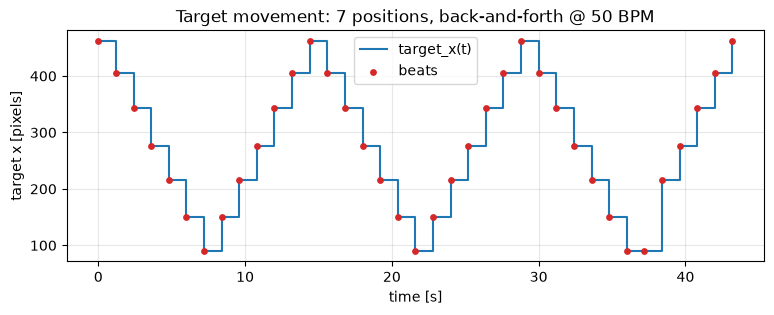

In [3]:
# Sanity check: plot a few cycles of the movement
n_cycles = 3
demo_beats = np.arange(0, n_cycles * PINGPONG_PERIOD + 1)
demo_t = demo_beats * beat_dt
demo_x = [target_x(t) for t in demo_t]

plt.figure(figsize=(9, 3))
plt.step(demo_t, demo_x, where="post", label="target_x(t)")
plt.scatter(demo_t, demo_x, color="tab:red", s=15, zorder=3, label="beats")
plt.xlabel("time [s]")
plt.ylabel("target x [pixels]")
plt.title(f"Target movement: 7 positions, back-and-forth @ {BPM} BPM")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 2. Train the CMAC online on this movement

Same online scheme as `cmac.py`'s `run_demo()` / `train_cmac.py`: keep a sliding window of the
last 3 *consecutive movements* (`x1, x2, x3`, one beat -- `beat_dt` -- apart), predict, then once
the true position `TIME_OF_FLIGHT` seconds after `x3` is known, compute the error and update the
CMAC's weights (covariance learning rule). `N_CENTERS` and `TIME_OF_FLIGHT` are the exact same
values `config.py` uses elsewhere in the project, so this mirrors what the CMAC actually has to
do live.


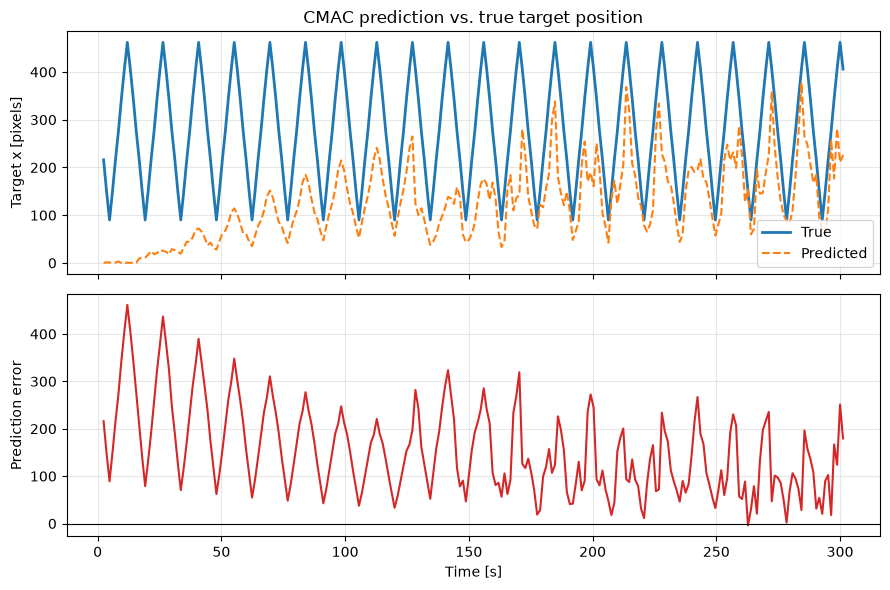

MSE first 20 predictions: 75548.71
MSE last 20 predictions:  14339.71
Learning: yes


In [4]:
cmac = CMAC3(
    n_centers=N_CENTERS,
    input_range=(pixel_x_vals.min(), pixel_x_vals.max()),
    beta=0.05,
)

N_TRAIN_BEATS = 250  # ~250 * 1.2s = 300s, matching config.WARMUP_DURATION

# Initialize the sliding window with the first 3 beats (3 consecutive movements)
window = [target_x(0), target_x(beat_dt), target_x(2 * beat_dt)]

times, y_true_hist, y_pred_hist = [], [], []

for beat in range(2, 2 + N_TRAIN_BEATS):
    t3 = beat * beat_dt
    x1, x2, x3 = window

    y_hat, B = cmac.predict(x1, x2, x3)
    y_true = target_x(t3 + TIME_OF_FLIGHT)  # position TIME_OF_FLIGHT seconds after x3

    error = y_true - y_hat
    cmac.update(B, error)

    times.append(t3)
    y_true_hist.append(y_true)
    y_pred_hist.append(y_hat)

    # slide the window forward by one movement/beat
    window = [x2, x3, target_x(t3 + beat_dt)]

plot_prediction(times, y_true_hist, y_pred_hist)
report_learning(y_true_hist, y_pred_hist)


## 3. Explicit test: given 3 consecutive movements, is the position 3 s later predicted correctly?

Picks out specific 3-movement sequences -- a rising run, a falling run, and sequences that
straddle a turnaround (where the sweep reverses direction) -- and checks the CMAC's prediction
against the true position 3 s later. "Correct" means the prediction lands closest to the actual
one of the 7 known positions.


In [5]:
def nearest_position(x):
    """Snaps a raw CMAC prediction to the closest of the 7 known positions."""
    idx = np.argmin(np.abs(pixel_x_vals - x))
    return pixel_x_vals[idx]


def test_window(start_beat, label=""):
    """Feeds the CMAC the 3 consecutive movements starting at start_beat and checks
    its prediction of the position TIME_OF_FLIGHT seconds after the 3rd one."""
    x1 = target_x(start_beat * beat_dt)
    x2 = target_x((start_beat + 1) * beat_dt)
    x3 = target_x((start_beat + 2) * beat_dt)
    t3 = (start_beat + 2) * beat_dt

    y_hat, _ = cmac.predict(x1, x2, x3)
    y_true = target_x(t3 + TIME_OF_FLIGHT)
    predicted_position = nearest_position(y_hat)
    correct = predicted_position == y_true

    print(label)
    print(f"  input sequence            : {x1:.0f} -> {x2:.0f} -> {x3:.0f}")
    print(f"  true position {TIME_OF_FLIGHT:.0f}s later    : {y_true:.0f}")
    print(f"  CMAC predicted             : {y_hat:.1f}  (nearest known position: {predicted_position:.0f})")
    print(f"  correct?                   : {'YES' if correct else 'no'}\n")
    return correct


# A few representative 3-movement sequences: rising run, falling run, and sequences
# that straddle a turnaround point (index 0 or index 6, where direction reverses).
test_window(0, "Rising run (start of a sweep)")
test_window(3, "Rising run approaching the right turnaround")
test_window(5, "Straddling the right turnaround (index 6 -> 5 -> 4)")
test_window(7, "Falling run")
_ = test_window(11, "Straddling the left turnaround (index 1 -> 0 -> 1)")

Rising run (start of a sweep)
  input sequence            : 462 -> 406 -> 344
  true position 3s later    : 216
  CMAC predicted             : 188.4  (nearest known position: 216)
  correct?                   : YES

Rising run approaching the right turnaround
  input sequence            : 276 -> 216 -> 150
  true position 3s later    : 150
  CMAC predicted             : 166.2  (nearest known position: 150)
  correct?                   : YES

Straddling the right turnaround (index 6 -> 5 -> 4)
  input sequence            : 150 -> 90 -> 150
  true position 3s later    : 276
  CMAC predicted             : 264.6  (nearest known position: 276)
  correct?                   : YES

Falling run
  input sequence            : 150 -> 216 -> 276
  true position 3s later    : 406
  CMAC predicted             : 394.0  (nearest known position: 406)
  correct?                   : YES

Straddling the left turnaround (index 1 -> 0 -> 1)
  input sequence            : 406 -> 462 -> 406
  true position 3s l

## 4. Overall accuracy across one full back-and-forth cycle

Every possible 3-consecutive-movement window within one full cycle (`PINGPONG_PERIOD` beats),
so the whole movement pattern -- both straight runs and both turnarounds -- gets checked.


In [6]:
n_correct = 0
results = []

for start_beat in range(PINGPONG_PERIOD):
    x1 = target_x(start_beat * beat_dt)
    x2 = target_x((start_beat + 1) * beat_dt)
    x3 = target_x((start_beat + 2) * beat_dt)
    t3 = (start_beat + 2) * beat_dt

    y_hat, _ = cmac.predict(x1, x2, x3)
    y_true = target_x(t3 + TIME_OF_FLIGHT)
    predicted_position = nearest_position(y_hat)
    correct = predicted_position == y_true
    n_correct += correct
    results.append((start_beat, x1, x2, x3, y_true, y_hat, correct))

print(f"Accuracy over one full back-and-forth cycle: {n_correct}/{PINGPONG_PERIOD} "
      f"({100 * n_correct / PINGPONG_PERIOD:.0f}%)\n")

for start_beat, x1, x2, x3, y_true, y_hat, correct in results:
    mark = "OK " if correct else "X  "
    print(f"{mark} beat {start_beat:2d}: {x1:.0f} -> {x2:.0f} -> {x3:.0f}   "
          f"true={y_true:.0f}   pred={y_hat:.1f}")


Accuracy over one full back-and-forth cycle: 10/12 (83%)

OK  beat  0: 462 -> 406 -> 344   true=216   pred=188.4
OK  beat  1: 406 -> 344 -> 276   true=150   pred=133.6
OK  beat  2: 344 -> 276 -> 216   true=90   pred=93.2
OK  beat  3: 276 -> 216 -> 150   true=150   pred=166.2
OK  beat  4: 216 -> 150 -> 90   true=216   pred=209.0
OK  beat  5: 150 -> 90 -> 150   true=276   pred=264.6
OK  beat  6: 90 -> 150 -> 216   true=344   pred=323.2
OK  beat  7: 150 -> 216 -> 276   true=406   pred=394.0
OK  beat  8: 216 -> 276 -> 344   true=462   pred=444.2
OK  beat  9: 276 -> 344 -> 406   true=406   pred=381.6
X   beat 10: 344 -> 406 -> 462   true=344   pred=305.4
X   beat 11: 406 -> 462 -> 406   true=276   pred=242.6
